In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import dask
import xesmf as xe
from numba import njit, prange

In [2]:
read_interpolated_data = True

# PATH_REGRIDDED = '/glade/campaign/cgd/oce/people/rita/ERA5_bias_correction/T2/'
PATH_OUT = '/glade/campaign/cgd/oce/people/rita/ERA5_bias_correction/T2/'

PATH_NCEP_R1 = '/glade/campaign/cgd/oce/people/rita/NCEP_R1/'
PATH_NCEP_R2 = '/glade/campaign/cgd/oce/people/rita/NCEP_R2/'
PATH_CFSR = '/glade/campaign/cgd/oce/people/rita/CFSR/'
PATH_CFSv2 = '/glade/campaign/cgd/oce/people/rita/CFSv2/'
PATH_MERRA2 = '/glade/campaign/cgd/oce/people/rita/MERRA2/'
PATH_JRA3Q = '/glade/campaign/cgd/oce/people/rita/JRA-3Q/'
PATH_JRAdo = '/glade/campaign/cgd/oce/people/rita/JRA55do/'
PATH_20CRv3 = '/glade/campaign/cgd/oce/people/rita/20CRv3/'
PATH_ERA5 = '/glade/campaign/cgd/oce/people/rita/ERA5/'
PATH_ERAi = '/glade/campaign/cgd/oce/people/rita/ERA-Interim/'

filename_NCEP_R1 = 'air.2m.gauss.monthly_1948_2025_regridded.nc'
filename_NCEP_R2 = 'air.2m.gauss.monthly_1979_2025_regridded.nc'
filename_CFSR = 'tmp2m.monthly_1979_2010_regridded.nc'
filename_CFSv2 = 'tmp2m.monthly_2011_2020_regridded.nc' 
filename_MERRA2 = 'T2M_MERRA2.monthly_1980_2024_regridded.nc'
filename_JRA3Q = 'tmp2m.monthly.1947_2025_regridded.nc'
filename_JRAdo = 't_2.converted.reg_tl319.monthly_1958_2019_regridded.nc'
filename_20CRv3 = 'air.2m.monthly.1900_2015_regridded.nc'
filename_ERA5 = 'T2M.monthly_1940_2020.nc'
filename_ERAi = 'tmp2m_monthly_1979_2019_regridded.nc'


varname_NCEP_R1 = 'air'
varname_NCEP_R2 = 'air'
varname_CFSR = '2t'
varname_CFSv2 = '2t'
varname_MERRA2 = 'T2M'
varname_JRA3Q = 'tmp2m-hgt-fc-gauss'
varname_JRAdo = 't_2'
varname_20CRv3 = 'air'
varname_ERA5 = 'T2M'
varname_ERAi = 'var167'

In [3]:
mask_era5 = xr.open_dataset(PATH_ERA5 + '1940/194001_hres_cisst.nc', decode_times=False).isel(time=0)
ocean_mask = xr.where(mask_era5.SSTK.notnull(), 1, 0)
# ocean_mask.to_netcdf(PATH_ERA5 + "era5_landsea_mask.nc")

# Read monthly mean data and obtain offset factors for 1980-2015

In [4]:
year_start = "1980"
year_fin = "2015"

In [5]:
%%time
t2_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + filename_NCEP_R1)[varname_NCEP_R1].sel(time=slice(year_start, year_fin))
t2_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + filename_NCEP_R2)[varname_NCEP_R2].sel(time=slice(year_start, year_fin)).isel(level =0, drop = True)
t2_cfsr_orig = xr.open_dataset(PATH_CFSR + filename_CFSR)[varname_CFSR].sel(time=slice(year_start, year_fin)).isel(height = 0, drop = True)
t2_cfsv2_orig = xr.open_dataset(PATH_CFSv2 + filename_CFSv2)[varname_CFSv2].sel(time=slice(year_start, year_fin)).isel(height = 0, drop = True)
t2_merra2 = xr.open_dataset(PATH_MERRA2 + filename_MERRA2)[varname_MERRA2].sel(time=slice(year_start, year_fin))
t2_jra3q = xr.open_dataset(PATH_JRA3Q + filename_JRA3Q)[varname_JRA3Q].sel(time=slice(year_start, year_fin))
t2_jrado = xr.open_dataset(PATH_JRAdo + filename_JRAdo)[varname_JRAdo].sel(time=slice(year_start, year_fin))#.rename({'latitude': 'lat', 'longitude':'lon'})
t2_20crv3 = xr.open_dataset(PATH_20CRv3 + filename_20CRv3)[varname_20CRv3].sel(time=slice(year_start, year_fin))
t2_era5 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5].sel(time=slice(year_start, year_fin))
t2_erai = xr.open_dataset(PATH_ERAi + filename_ERAi)[varname_ERAi].sel(time=slice(year_start, year_fin))


t2_cfsr_raw = xr.concat([t2_cfsr_orig, t2_cfsv2_orig], dim="rean").mean(dim="rean", skipna=True)


t2_cfsr = t2_cfsr_raw.sel(time=~((t2_cfsr_raw['time.month'] == 1) & (t2_cfsr_raw['time.day'] == 1)))

CPU times: user 5.55 s, sys: 11.2 s, total: 16.8 s
Wall time: 56.8 s


In [6]:
# missing_values = t2_erai.isnull().sum().item()
# missing_values

# Compute monthly mean offset factors for years 1980-2015

In [7]:
%%time

# Stack your reanalysis fields in this order
reanal_data = np.stack([
    t2_ncep_r1.values,
    t2_ncep_r2.values,
    t2_cfsr.values,
    t2_merra2.values,
    t2_jra3q.values,
    t2_20crv3.values,
    t2_erai.values
])  # shape = (n_model, time, lat, lon)

era5_data = t2_era5.values

weights_base = np.array([0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])


@njit(parallel=True)
def compute_offset(reanal_data, era5_data, weights_base):
    n_model, n_time, n_lat, n_lon = reanal_data.shape
    offset = np.full((n_time, n_lat, n_lon), np.nan)

    for t in range(n_time):
        if t%10==0:
            print(str(t)+'/'+str(n_time-1))
        for y in range(n_lat):
            for x in range(n_lon):
                vals = reanal_data[:, t, y, x]
                weights = weights_base.copy()

                # Mask NaNs
                valid_idxs = [i for i in range(n_model) if not np.isnan(vals[i])]
                if len(valid_idxs) == 0:
                    continue

                # Extract valid values and weights
                vals_valid = np.array([vals[i] for i in valid_idxs])
                weights_valid = np.array([weights[i] for i in valid_idxs])

                # Adjust min and max
                min_idx = np.argmin(vals_valid)
                max_idx = np.argmax(vals_valid)
                weights_valid[min_idx] *= 0.5
                weights_valid[max_idx] *= 0.5

                weight_sum = weights_valid.sum()
                if weight_sum > 0:
                    wmean = np.sum(vals_valid * weights_valid) / weight_sum
                    era5_val = era5_data[t, y, x]
                    if not np.isnan(era5_val):
                        offset[t, y, x] = era5_val - wmean

    return offset


offset = compute_offset(reanal_data, era5_data, weights_base)


0/431
10/431
20/431
30/431
40/431
50/431
60/431
70/431
80/431
90/431
100/431
110/431
120/431
130/431
140/431
150/431
160/431
190/431
200/431
210/431
220/431
230/431
240/431
250/431
260/431
270/431
280/431
290/431
300/431
310/431
320/431
330/431
340/431
350/431
360/431
370/431
380/431
390/431
400/431
410/431
420/431
430/431
CPU times: user 35min 18s, sys: 42.9 s, total: 36min 1s
Wall time: 43min 50s


In [1]:
offset_da = xr.DataArray(
    offset,
    dims=["time", "lat", "lon"],
    coords={
        "time": t2_era5["time"],
        "lat": t2_era5["lat"],
        "lon": t2_era5["lon"]
    },
    name="t2_offset"
)

offset_da.to_netcdf(PATH_OUT + 'T2_offset_monthly_' + str(year_start) + '_' + str(year_fin) + '.nc')

NameError: name 'xr' is not defined

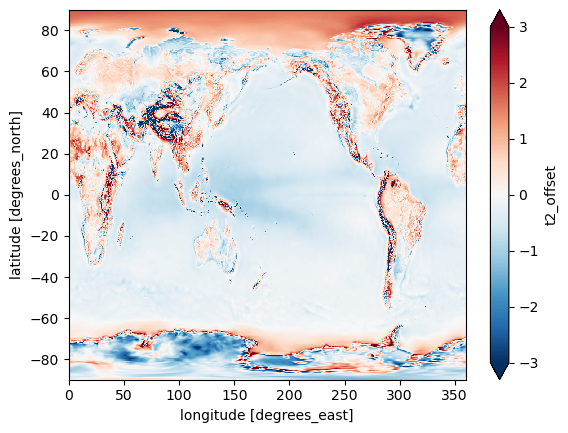

In [14]:
offset_da.mean('time').plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')

In [15]:
monthly_mean_offsets = offset_da.groupby('time.month').mean(dim='time')
monthly_mean_offsets.to_netcdf(PATH_OUT + 'T2_monthly_mean_offsets_monthly_' + str(year_start) + '_' + str(year_fin) +'.nc')

# Read monthly mean data and obtain offset factors for 1958-1979

In [4]:
year_start = "1958"
year_fin = "1979"

In [8]:
%%time
t2_ncep_r1 = xr.open_dataset(PATH_NCEP_R1 + filename_NCEP_R1)[varname_NCEP_R1].sel(time=slice(year_start, year_fin))
# t2_ncep_r2 = xr.open_dataset(PATH_NCEP_R2 + filename_NCEP_R2)[varname_NCEP_R2].sel(time=slice(year_start, year_fin)).isel(level =0, drop = True)
# t2_cfsr_orig = xr.open_dataset(PATH_CFSR + filename_CFSR)[varname_CFSR].sel(time=slice(year_start, year_fin)).isel(height = 0, drop = True)
# t2_cfsv2_orig = xr.open_dataset(PATH_CFSv2 + filename_CFSv2)[varname_CFSv2].sel(time=slice(year_start, year_fin)).isel(height = 0, drop = True)
# t2_merra2 = xr.open_dataset(PATH_MERRA2 + filename_MERRA2)[varname_MERRA2].sel(time=slice(year_start, year_fin))
t2_jra3q = xr.open_dataset(PATH_JRA3Q + filename_JRA3Q)[varname_JRA3Q].sel(time=slice(year_start, year_fin))
# t2_jrado = xr.open_dataset(PATH_JRAdo + filename_JRAdo)[varname_JRAdo].sel(time=slice(year_start, year_fin))#.rename({'latitude': 'lat', 'longitude':'lon'})
t2_20crv3 = xr.open_dataset(PATH_20CRv3 + filename_20CRv3)[varname_20CRv3].sel(time=slice(year_start, year_fin))
t2_era5 = xr.open_dataset(PATH_ERA5 + filename_ERA5)[varname_ERA5].sel(time=slice(year_start, year_fin))
# t2_erai = xr.open_dataset(PATH_ERAi + filename_ERAi)[varname_ERAi].sel(time=slice(year_start, year_fin))


# t2_cfsr_raw = xr.concat([t2_cfsr_orig, t2_cfsv2_orig], dim="rean").mean(dim="rean", skipna=True)


# t2_cfsr = t2_cfsr_raw.sel(time=~((t2_cfsr_raw['time.month'] == 1) & (t2_cfsr_raw['time.day'] == 1)))

CPU times: user 27.9 ms, sys: 37.8 ms, total: 65.6 ms
Wall time: 269 ms


# Compute monthly mean offset factors for years 1958-1979

In [9]:
%%time

# Stack your reanalysis fields in this order
reanal_data = np.stack([
    t2_ncep_r1.values,
    # t2_ncep_r2.values,
    # t2_cfsr.values,
    # t2_merra2.values,
    t2_jra3q.values,
    t2_20crv3.values,
    # t2_erai.values
])  # shape = (n_model, time, lat, lon)

era5_data = t2_era5.values

weights_base = np.array([0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0])


@njit(parallel=True)
def compute_offset(reanal_data, era5_data, weights_base):
    n_model, n_time, n_lat, n_lon = reanal_data.shape
    offset = np.full((n_time, n_lat, n_lon), np.nan)

    for t in range(n_time):
        if t%10==0:
            print(str(t)+'/'+str(n_time-1))
        for y in range(n_lat):
            for x in range(n_lon):
                vals = reanal_data[:, t, y, x]
                weights = weights_base.copy()

                # Mask NaNs
                valid_idxs = [i for i in range(n_model) if not np.isnan(vals[i])]
                if len(valid_idxs) == 0:
                    continue

                # Extract valid values and weights
                vals_valid = np.array([vals[i] for i in valid_idxs])
                weights_valid = np.array([weights[i] for i in valid_idxs])

                # # Adjust min and max
                # min_idx = np.argmin(vals_valid)
                # max_idx = np.argmax(vals_valid)
                # weights_valid[min_idx] *= 0.5
                # weights_valid[max_idx] *= 0.5

                weight_sum = weights_valid.sum()
                if weight_sum > 0:
                    wmean = np.sum(vals_valid * weights_valid) / weight_sum
                    era5_val = era5_data[t, y, x]
                    if not np.isnan(era5_val):
                        offset[t, y, x] = era5_val - wmean

    return offset


offset = compute_offset(reanal_data, era5_data, weights_base)


0/263
10/263
20/263
30/263
40/263
50/263
60/263
70/263
80/263
90/263
100/263
110/263
120/263
130/263
140/263
150/263
160/263
170/263
180/263
190/263
200/263
210/263
220/263
230/263
240/263
250/263
260/263
CPU times: user 10min 19s, sys: 10 s, total: 10min 29s
Wall time: 14min 40s


In [10]:
offset_da = xr.DataArray(
    offset,
    dims=["time", "lat", "lon"],
    coords={
        "time": t2_era5["time"],
        "lat": t2_era5["lat"],
        "lon": t2_era5["lon"]
    },
    name="t2_offset"
)

offset_da.to_netcdf(PATH_OUT + 'T2_offset_monthly_' + str(year_start) + '_' + str(year_fin) + '.nc')

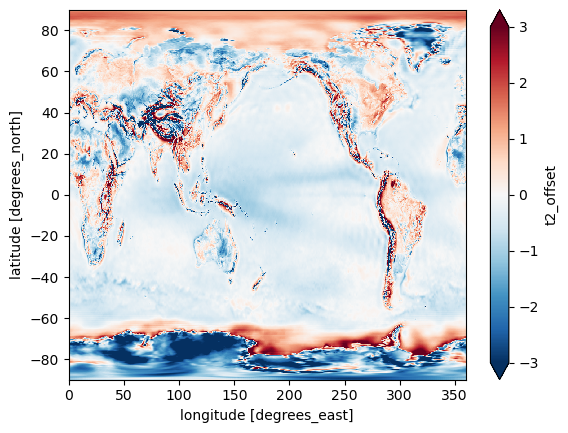

In [11]:
offset_da.mean('time').plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')

In [12]:
monthly_mean_offsets = offset_da.groupby('time.month').mean(dim='time')
monthly_mean_offsets.to_netcdf(PATH_OUT + 'T2_monthly_mean_offsets_monthly_' + str(year_start) + '_' + str(year_fin) +'.nc')